# 5.0 Revenue Drivers Overview

- This notebook deepens the analysis of what drives revenue for Buenavista.
- The objective is to identify which patterns, customer behaviors, and operating windows contribute most to sales performance.
- This layer builds on the KPI, business analysis, and strategy notebooks by quantifying the strongest revenue levers.
- Analysis will focus on:
  - revenue concentration
  - peak vs off-peak contribution
  - high-value order behavior
  - AOV drivers
  - operational revenue opportunities
- SQL will be used for structured revenue driver queries.
- Python will be used for validation, visualization, and interpretation.
- The goal is to move from broad recommendations into a deeper understanding of where revenue is actually created.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DuckDB
con = duckdb.connect(database=':memory:')

# Reload cleaned dataset
con.execute("""
CREATE OR REPLACE TABLE orders_clean AS
SELECT * FROM read_csv_auto('data/cleaned/orders_clean.csv');
""")

# Quick validation
con.execute("SELECT COUNT(*) FROM orders_clean").fetchdf()

,count_star()
0,22156


## 5.1 Revenue Concentration (Pareto Analysis)

- Analyze how revenue is distributed across orders.
- Determine whether a small percentage of orders drives a large portion of total revenue.
- This follows the Pareto principle (80/20 rule).
- Identifying concentration helps understand whether growth depends on:
  - high-value orders
  - or broad transaction volume

In [4]:
rev_dist_df = con.execute("""
SELECT
    order_total
FROM orders_clean
ORDER BY order_total DESC
""").fetchdf()

rev_dist_df.head()

,order_total
0,361.20
1,259.00
2,198.96
3,189.00
4,184.71


## 5.2 Cumulative Revenue Distribution

- Calculate cumulative revenue contribution across sorted orders.
- Determine how quickly revenue accumulates.
- Identify what percentage of orders contributes to the majority of revenue.

In [5]:
rev_dist_df['cumulative_revenue'] = rev_dist_df['order_total'].cumsum()
total_rev = rev_dist_df['order_total'].sum()

rev_dist_df['cumulative_pct'] = (rev_dist_df['cumulative_revenue'] / total_rev) * 100
rev_dist_df['order_rank_pct'] = (rev_dist_df.index + 1) / len(rev_dist_df) * 100

rev_dist_df.head()

,order_total,cumulative_revenue,cumulative_pct,order_rank_pct
0,361.20,361.20,0.062568,0.004513
1,259.00,620.20,0.107433,0.009027
2,198.96,819.16,0.141897,0.013540
3,189.00,1008.16,0.174636,0.018054
4,184.71,1192.87,0.206632,0.022567


## 5.3 Pareto Curve Visualization

- Visualize cumulative revenue vs cumulative order percentage.
- Identify how concentrated revenue is.
- This reveals whether a small number of orders drive most revenue.

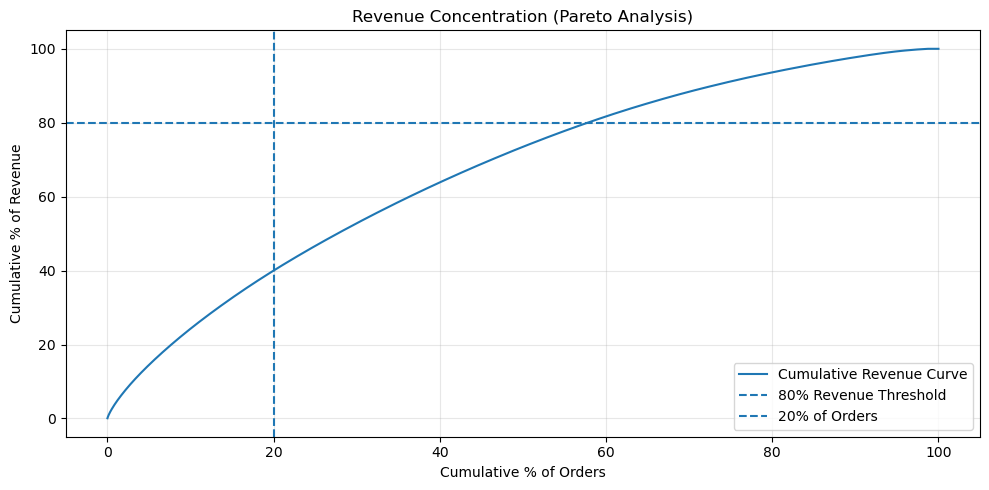

In [7]:
plt.figure(figsize=(10,5))

# Main Pareto curve
plt.plot(
    rev_dist_df['order_rank_pct'],
    rev_dist_df['cumulative_pct'],
    label='Cumulative Revenue Curve'
)

# Reference lines
plt.axhline(80, linestyle='--', label='80% Revenue Threshold')
plt.axvline(20, linestyle='--', label='20% of Orders')

# Labels and title
plt.title('Revenue Concentration (Pareto Analysis)')
plt.xlabel('Cumulative % of Orders')
plt.ylabel('Cumulative % of Revenue')

# Legend
plt.legend()

# Grid for readability
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Peak vs Off-Peak Revenue Split

- Quantify how much revenue is generated during peak vs off-peak hours.
- Translate earlier time-based insights into clear revenue contribution percentages.
- Define peak hours based on prior analysis (lunch + dinner windows).
- This section measures how dependent the business is on peak demand and how large the off-peak opportunity is.

In [8]:
peak_split_df = con.execute("""
SELECT
    CASE
        WHEN EXTRACT(HOUR FROM order_datetime) BETWEEN 11 AND 13
          OR EXTRACT(HOUR FROM order_datetime) BETWEEN 17 AND 19
        THEN 'Peak'
        ELSE 'Off-Peak'
    END AS time_segment,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY time_segment
""").fetchdf()

peak_split_df

,time_segment,total_orders,total_revenue
0,Off-Peak,5593,140917.73
1,Peak,16563,436373.93


In [9]:
total_rev = peak_split_df['total_revenue'].sum()

peak_split_df['revenue_share_pct'] = (
    peak_split_df['total_revenue'] / total_rev
) * 100

peak_split_df['order_share_pct'] = (
    peak_split_df['total_orders'] / peak_split_df['total_orders'].sum()
) * 100

peak_split_df

,time_segment,total_orders,total_revenue,revenue_share_pct,order_share_pct
0,Off-Peak,5593,140917.73,24.410145,25.243726
1,Peak,16563,436373.93,75.589855,74.756274


## 5.5 Peak vs Off-Peak Revenue Distribution

- Visualize how revenue is split between peak and off-peak periods.
- Highlight dependency on peak demand and size of off-peak opportunity.

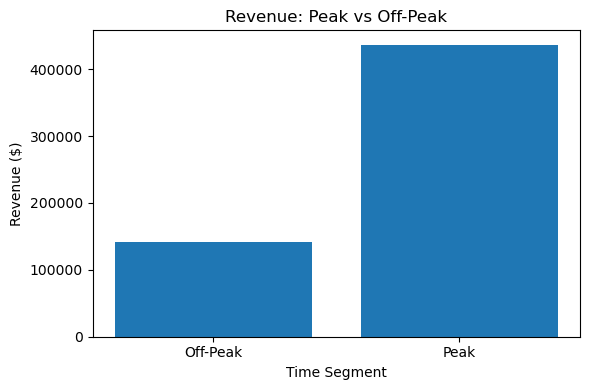

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    peak_split_df['time_segment'],
    peak_split_df['total_revenue']
)

plt.title('Revenue: Peak vs Off-Peak')
plt.xlabel('Time Segment')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

## 5.6 High-Value Order Behavior

- Identify what differentiates high-value orders from typical transactions.
- Define “high-value” using a percentile threshold (e.g., top 20% of orders by value).
- Compare high-value vs standard orders across:
  - guest count
  - time of day
  - day of week
- This reveals what conditions lead to larger tickets and where to replicate them.

In [11]:
# Define high-value threshold (top 20%)
threshold = con.execute("""
SELECT
    PERCENTILE_CONT(0.8) WITHIN GROUP (ORDER BY order_total) AS p80
FROM orders_clean
""").fetchdf()['p80'][0]

high_value_df = con.execute(f"""
SELECT
    CASE 
        WHEN order_total >= {threshold} THEN 'High-Value'
        ELSE 'Standard'
    END AS order_type,
    COUNT(*) AS total_orders,
    AVG(order_total) AS avg_order_value,
    SUM(order_total) AS total_revenue,
    AVG(guest_count) AS avg_guest_count
FROM orders_clean
GROUP BY order_type
""").fetchdf()

high_value_df

,order_type,total_orders,avg_order_value,total_revenue,avg_guest_count
0,High-Value,4432,52.121861,231004.09,1.740072
1,Standard,17724,19.537778,346287.57,1.110697


## 5.7 High-Value Orders by Hour

- Determine when high-value orders occur.
- Identify whether larger tickets cluster in specific time windows.

In [12]:
high_hour_df = con.execute(f"""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    AVG(order_total) AS avg_order_value
FROM orders_clean
WHERE order_total >= {threshold}
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY order_hour
""").fetchdf()

high_hour_df

,order_hour,total_orders,avg_order_value
0,10,6,43.940000
1,11,655,53.976473
2,12,697,54.970846
3,13,284,50.633099
4,14,203,51.356453
5,15,281,51.455872
6,16,510,49.317333
7,17,764,50.079673
8,18,688,52.310930
9,19,343,53.500875


## 5.8 High-Value Order Visualization

- Visualize timing of high-value orders.
- Compare with overall demand patterns to spot leverage points.

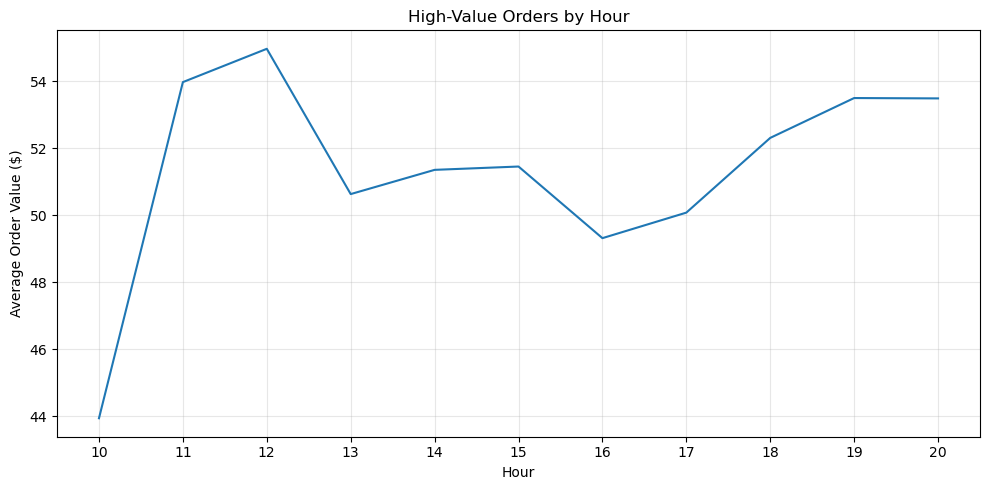

In [13]:
plt.figure(figsize=(10,5))
plt.plot(high_hour_df['order_hour'], high_hour_df['avg_order_value'])
plt.title('High-Value Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Order Value ($)')
plt.xticks(range(10,21))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.9 High-Value Order Replication Strategy

- Translate high-value order patterns into repeatable tactics.
- Use findings from prior sections:
  - high-value orders cluster around lunch and dinner
  - AOV increases with guest count
  - most transactions are single-guest
- The objective is to increase the frequency of high-value orders without relying on discounts.

### Key Insights to Leverage

- High-value orders are most common during structured meal times (11–12, 17–19).
- Larger group sizes strongly correlate with higher AOV.
- Mid-afternoon periods (13–16) show lower AOV and represent a conversion opportunity.

### Strategic Actions

- **Replicate Meal Behavior in Off-Peak Hours**
  - Introduce “mini-meal” positioning during mid-afternoon (13–16) to encourage full-order behavior instead of light/snack purchases.
  - Frame offerings as complete meals rather than individual items.

- **Encourage Small Group Ordering**
  - Target 2–4 guest orders, where AOV increases significantly.
  - Use messaging and menu structure that promotes sharing or adding items.

- **Low-Friction Add-On System**
  - Standardize prompts for adding drinks, sides, or desserts to single-guest orders.
  - Focus on quick, easy additions that do not slow down service.

- **Bundle Without Discounting**
  - Create perceived value bundles rather than price-reduction promotions.
  - Maintain margin while increasing total ticket size.

- **Time-Specific Menu Positioning**
  - Highlight higher-value combinations during lunch and dinner windows.
  - Use simplified decision paths during peak hours to maximize order size and speed.

### Expected Impact

- Increased frequency of high-value orders across more hours of operation
- Higher overall AOV without increasing reliance on discounts
- Better utilization of underperforming time windows
- Stronger alignment between customer behavior and revenue optimization

## 5.10 Revenue Drivers Summary

- This section consolidates all findings from the Revenue Drivers analysis into a clear, structured understanding of how revenue is generated and how it can be scaled.
- The goal is to identify the most important levers for growth and how they interact.

### Key Revenue Drivers

- **Time-Based Demand Concentration**
  - Approximately 76% of total revenue is generated during peak hours (lunch and dinner windows).
  - Revenue is heavily dependent on a limited set of high-demand periods.
  - These windows represent both the strongest revenue engine and the greatest operational constraint.

- **Volume-Driven Revenue Model**
  - Pareto analysis shows that revenue is broadly distributed across orders rather than concentrated in a small subset.
  - Growth is driven by increasing total transactions and small improvements in AOV across many orders.

- **AOV Driven by Guest Count**
  - Average order value increases significantly with guest count.
  - Larger group sizes contribute disproportionately higher revenue per transaction.
  - However, most orders are single-guest, limiting natural AOV expansion.

- **High-Value Orders Cluster Around Meal Times**
  - High-value orders are most common during lunch and dinner hours.
  - Mid-afternoon periods show lower AOV and fewer high-value transactions.
  - Customer behavior aligns strongly with structured meal patterns.

- **Underutilized Off-Peak Hours**
  - A meaningful portion of operating hours generates minimal revenue.
  - These periods represent the largest opportunity for incremental growth without increasing fixed costs.

### Integrated Insight

- Revenue is primarily driven by:
  - when customers order (time-based demand)
  - how many items they purchase (AOV / guest count)
- The business is not dependent on rare high-value transactions, but on consistent performance across many orders.

- The most effective growth strategy is to:
  - maximize efficiency during peak hours
  - increase AOV for single-guest transactions
  - expand demand and order size during off-peak periods

### Final Takeaway

- Buenavista operates as a **volume-driven, time-concentrated business**.
- Growth will come from:
  - improving throughput during peak windows
  - increasing order value across the majority of transactions
  - converting underutilized hours into productive revenue periods

- The next stage will focus on forecasting demand and aligning operations to support sustainable growth.

## 5.11 SQL Revenue Drivers (Order-Level)

- Analyze revenue drivers using order-level data.
- Identify how revenue is distributed across time and customer behavior.
- Focus on high-impact segments instead of individual items.

In [2]:
import pandas as pd
import duckdb

# Load cleaned dataset
orders_clean = pd.read_csv("../data/cleaned/orders_clean.csv")

# Restore datetime
orders_clean["order_datetime"] = pd.to_datetime(orders_clean["order_datetime"])

# DuckDB connection
con = duckdb.connect()
con.register("orders_clean", orders_clean)

# SQL Revenue Drivers (by hour)
con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    ROUND(AVG(order_total), 2) AS avg_order_value
FROM orders_clean
GROUP BY order_hour
ORDER BY total_revenue DESC
""").fetchdf()

,order_hour,total_orders,total_revenue,avg_order_value
0,11,3841,92533.05,24.09
1,17,3224,90153.19,27.96
2,12,3259,86567.47,26.56
3,18,2838,81880.89,28.85
4,16,2517,66872.10,26.57
5,13,1841,42734.53,23.21
6,19,1560,42504.80,27.25
7,15,1617,40481.66,25.04
8,14,1381,32313.08,23.40
9,10,64,1024.07,16.00
